In [1]:
#!pip install pmdarima

## LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mp
import seaborn as sns
import plotly as plt
import os
import openpyxl
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#quitar warning
import warnings
warnings.filterwarnings('ignore')
from pmdarima import auto_arima

## LECTURA DE DATASETS

In [3]:
import pandas as pd
import os

# Ruta de tu carpeta (ajústala si es necesario)
folder_path = r'.\archivos_mayorista' 

files = [
    "anex-SIPSA-SerieHistoricaMayorista-2024.xlsx",
    "anex-SIPSA-SerieHistoricaMayorista-Dic2023.xlsx",
    "series-historicas-precios-mayoristas-2013-2017.xlsx",
    "series-historicas-precios-mayoristas-2018.xlsx",
    "series-historicas-precios-mayoristas-2019.xlsx",
    "series-historicas-precios-mayoristas-2020.xlsx",
    "series-historicas-precios-mayoristas-2021.xlsx",
    "series-historicas-precios-mayoristas-2022.xlsx"
]

for file in files:
    file_path = os.path.join(folder_path, file)
    print(f"\n{'='*60}")
    print(f"ARCHIVO: {file}")
    
    try:
        # Cargamos el Excel completo para ver los nombres de las hojas
        xls = pd.ExcelFile(file_path)
        print(f"Hojas encontradas: {xls.sheet_names}")
        
        for sheet in xls.sheet_names:
            # Leemos solo las primeras 5 filas para inspeccionar
            df = pd.read_excel(file_path, sheet_name=sheet, nrows=5)
            print(f"\n--- Hoja: {sheet} ---")
            print("Columnas detectadas:", df.columns.tolist())
            print("Vista previa (head):")
            print(df)
            
    except Exception as e:
        print(f"Error al leer {file}: {e}")


ARCHIVO: anex-SIPSA-SerieHistoricaMayorista-2024.xlsx
Hojas encontradas: ['2024']

--- Hoja: 2024 ---
Columnas detectadas: ['Fecha', 'Grupo', 'Producto', 'Mercado', 'Precio promedio por kilogramo*']
Vista previa (head):
       Fecha                  Grupo Producto                       Mercado  \
0 2024-01-01  VERDURAS Y HORTALIZAS   Acelga               Armenia, Mercar   
1 2024-01-01  VERDURAS Y HORTALIZAS   Acelga      Bogotá, D.C., Corabastos   
2 2024-01-01  VERDURAS Y HORTALIZAS   Acelga    Bucaramanga, Centroabastos   
3 2024-01-01  VERDURAS Y HORTALIZAS   Acelga         Chiquinquirá (Boyacá)   
4 2024-01-01  VERDURAS Y HORTALIZAS   Acelga  Duitama (Boyacá), Mercaplaza   

   Precio promedio por kilogramo*  
0                            1387  
1                             607  
2                            2000  
3                            1896  
4                            2000  

ARCHIVO: anex-SIPSA-SerieHistoricaMayorista-Dic2023.xlsx
Hojas encontradas: ['Enero', 'Febrer

## CONSOLIDACION DEL DATASET

In [4]:
def consolidar_sipsa_2025(ruta_carpeta):
    todos_los_datos = []
    archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith('.xlsx')]
    
    for archivo in archivos:
        ruta_completa = os.path.join(ruta_carpeta, archivo)
        xls = pd.ExcelFile(ruta_completa)
        
        for nombre_hoja in xls.sheet_names:
            df = pd.read_excel(ruta_completa, sheet_name=nombre_hoja)
            
            # Limpiar nombres de columnas (quitar espacios y poner en minúsculas)
            df.columns = [str(c).strip().lower() for c in df.columns]
            
            # Diccionario de normalización automática
            mapeo = {}
            for col in df.columns:
                if 'precio' in col: mapeo[col] = 'precio_kg'
                elif 'mercado' in col or 'fuente' in col: mapeo[col] = 'mercado'
                elif 'fecha' in col: mapeo[col] = 'fecha'
                elif 'producto' in col: mapeo[col] = 'producto'
                elif 'grupo' in col: mapeo[col] = 'grupo'
            
            df = df.rename(columns=mapeo)
            
            # Seleccionar solo las columnas necesarias si existen
            columnas_finales = ['fecha', 'grupo', 'producto', 'mercado', 'precio_kg']
            df = df[[c for c in columnas_finales if c in df.columns]]
            
            todos_los_datos.append(df)
            
    # Concatenar todo
    df_maestro = pd.concat(todos_los_datos, ignore_index=True)
    
    # Limpieza final de formatos
    df_maestro['fecha'] = pd.to_datetime(df_maestro['fecha'], errors='coerce')
    df_maestro['precio_kg'] = pd.to_numeric(df_maestro['precio_kg'], errors='coerce')
    df_maestro = df_maestro.dropna(subset=['fecha', 'precio_kg', 'producto'])
    
    return df_maestro.sort_values('fecha')

# Ejecución
df_final = consolidar_sipsa_2025(folder_path)
print(df_final.head())
df_final.to_csv('sipsa_consolidado_2025.csv', index=False)

            fecha       grupo                producto  \
163158 2013-01-01      CARNES  Carne de res, paletero   
165588 2013-01-01  PROCESADOS       Mayonesa doy pack   
165589 2013-01-01  PROCESADOS       Mayonesa doy pack   
165590 2013-01-01  PROCESADOS       Mayonesa doy pack   
165591 2013-01-01  PROCESADOS       Mayonesa doy pack   

                                         mercado  precio_kg  
163158                 Bucaramanga, Frigoríficos    11000.0  
165588                Manizales, Centro Galerías    14372.0  
165589  Medellín, Central Mayorista de Antioquia    10892.0  
165590                 Palmira (Valle del Cauca)    13167.0  
165591                      Pasto, El Potrerillo    12647.0  


## Diccionario de Datos


| Campo | Tipo de Dato | Descripción | Ejemplo |
| :--- | :--- | :--- | :--- |
| **fecha** | DATETIME | Fecha y hora del registro (ISO 8601). | 2013-01-01 00:00:00 |
| **grupo** | STRING / CATEGORICAL | Categoría general del producto. | PROCESADOS |
| **producto** | STRING | Nombre específico del artículo. | MAYONESA DOY PACK |
| **mercado** | STRING | Ubicación o central de abastos. | BUCARAMANGA, FRIGORIFICOS |
| **precio_kg** | FLOAT / DOUBLE | Valor numérico del precio por kilogramo. | 11000.0 |


In [24]:
df_final.head(10)

,fecha,grupo,producto,mercado,precio_kg
163158,2013-01-01,CARNES,"CARNE DE RES, PALETERO","BUCARAMANGA, FRIGORIFICOS",11000.0
165588,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"MANIZALES, CENTRO GALERIAS",14372.0
165589,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"MEDELLIN, CENTRAL MAYORISTA DE ANTIOQUIA",10892.0
165590,2013-01-01,PROCESADOS,MAYONESA DOY PACK,PALMIRA (VALLE DEL CAUCA),13167.0
165591,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"PASTO, EL POTRERILLO",12647.0
165592,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"POPAYAN, PLAZA DE MERCADO DEL BARRIO BOLIVAR",14130.0
165593,2013-01-01,PROCESADOS,MAYONESA DOY PACK,TULUA (VALLE DEL CAUCA),13667.0
165594,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"VALLEDUPAR, MERCADO NUEVO",14600.0
165595,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"VILLAVICENCIO, CAV",14444.0
165596,2013-01-01,PROCESADOS,PANELA CUADRADA BLANCA,"BARRANQUILLA, BARRANQUILLITA",1718.0


## VERIFICACION DE LA CALIDAD DE LOS DATOS 1

In [5]:
def auditoria_calidad(df):
    print("--- REPORTE DE CALIDAD PARA SARIMA ---")
    
    # 1. Registros por año (Ver cobertura)
    print("\n1. Cobertura Temporal (Filas por año):")
    print(df['fecha'].dt.year.value_counts().sort_index())
    
    # 2. Valores Nulos
    print("\n2. Valores Nulos por Columna:")
    print(df.isnull().sum())
    
    # 3. Análisis de un producto "Termómetro" (ej. PAPA UNICA)
    # Cambia 'PAPA UNICA' por el nombre exacto que tengas
    df_papa = df[df['producto'].str.contains('PAPA', na=False)]
    if df_papa.empty:
        print("\n3. No se encontró ningún producto que contenga 'PAPA'.")
    else:
        producto_test = df_papa['producto'].iloc[0]
        df_test = df[df['producto'] == producto_test].resample('MS', on='fecha')['precio_kg'].mean()

        # 4. Detectar huecos meses faltantes
        rango_completo = pd.date_range(start=df['fecha'].min(), end=df['fecha'].max(), freq='MS')
        meses_faltantes = rango_completo.difference(df_test.index)

        print(f"\n3. Diagnóstico para {producto_test}:")
        print(f"- Meses faltantes en la serie: {len(meses_faltantes)}")
        if len(meses_faltantes) > 0:
            print(f"- Ejemplo de meses faltantes: {meses_faltantes[:3]}")
        
    # 5. Estadísticos rápidos de precio
    print("\n4. Estadísticos de Precio (Detectar ceros o errores):")
    print(df['precio_kg'].describe())

auditoria_calidad(df_final)

--- REPORTE DE CALIDAD PARA SARIMA ---

1. Cobertura Temporal (Filas por año):
fecha
2013    54676
2014    56334
2015    55958
2016    57026
2017    57392
2018    57121
2019    56626
2020    55716
2021    54528
2022    53647
2023    53807
2024    54042
2025    54408
Name: count, dtype: int64

2. Valores Nulos por Columna:
fecha        0
grupo        0
producto     0
mercado      0
precio_kg    0
dtype: int64

3. No se encontró ningún producto que contenga 'PAPA'.

4. Estadísticos de Precio (Detectar ceros o errores):
count    721281.000000
mean       7146.942211
std       10603.269603
min          82.000000
25%        1548.000000
50%        3303.000000
75%        9257.000000
max      266667.000000
Name: precio_kg, dtype: float64


## VERIFICACION #2

Tus primeros 10 productos son:
['Carne de res, paletero' 'Mayonesa doy pack' 'Panela cuadrada blanca'
 'Panela cuadrada morena' 'Manteca' 'Margarina' 'Pastas alimenticias'
 'Sal yodada' 'Panela redonda morena' 'Papa frita']

Graficando historial para: Papa frita


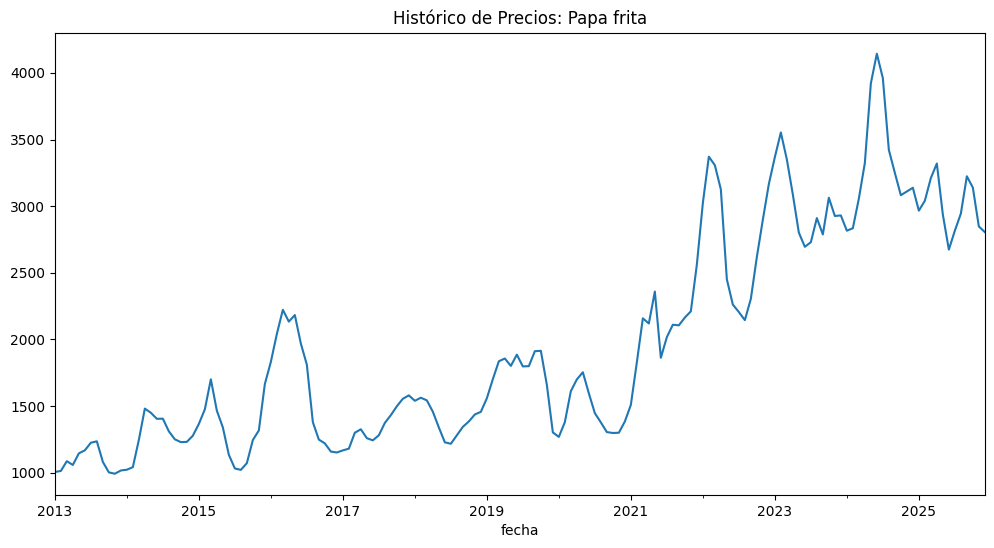

In [ ]:
# 1. Ver qué productos tienes realmente (Primeros 10)
print("Tus primeros 10 productos son:")
print(df_final['producto'].unique()[:10])

# 2. Intentar graficar uno de forma segura (ignora mayúsculas/minúsculas)
producto_a_graficar = "PAPA" # Escríbelo como quieras
df_test = df_final[df_final['producto'].str.upper().str.contains(producto_a_graficar.upper())]

if not df_test.empty:
    nombre_real = df_test['producto'].iloc[0]
    print(f"\nGraficando historial para: {nombre_real}")
    
    # Agrupar por mes para limpiar el ruido
    serie_mensual = df_test.resample('MS', on='fecha')['precio_kg'].mean()
    serie_mensual.plot(figsize=(12,6), title=f"Histórico de Precios: {nombre_real}")
else:
    print(f"\nNo se encontró ningún producto que contenga '{producto_a_graficar}'")

## Limpieza #1

In [7]:
import unicodedata

def limpiar_texto(texto):
    if not isinstance(texto, str): return texto
    # Quitar acentos y eñes
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    # Mayúsculas y sin espacios laterales
    return texto.strip().upper()

# 1. Aplicar limpieza de texto a todas las categorías
for col in ['grupo', 'producto', 'mercado']:
    df_final[col] = df_final[col].apply(limpiar_texto)

# 2. Eliminar precios en cero o negativos (si existen)
df_final = df_final[df_final['precio_kg'] > 0]

# 3. Identificar Outliers (Precios sospechosos)
# Filtramos precios que sean 5 veces mayores al promedio del mismo producto
stats = df_final.groupby('producto')['precio_kg'].transform('median')
df_final = df_final[df_final['precio_kg'] < (stats * 10)] # Umbral conservador

print("✅ Texto normalizado y outliers extremos eliminados.")
print(f"Total de productos únicos: {df_final['producto'].nunique()}")
print(f"Total de mercados únicos: {df_final['mercado'].nunique()}")

✅ Texto normalizado y outliers extremos eliminados.
Total de productos únicos: 383
Total de mercados únicos: 106


## Paso 1: Identificación de Parámetros (ACF y PACF)

In [8]:
# Ver los primeros 20 productos para ver el formato exacto
print("Formatos reales de productos en la base:")
print(list(df_final['producto'].unique()[:20]))

# Buscar cualquier cosa que se parezca a PAPA
filtro_papa = df_final[df_final['producto'].str.contains('PAPA', na=False, case=False)]
if not filtro_papa.empty:
    nombre_exacto = filtro_papa['producto'].iloc[0]
    print(f"\n✅ ¡Encontrado! El nombre exacto es: '{nombre_exacto}'")
    print(f"Número de filas con este nombre: {len(filtro_papa)}")
else:
    print("\n❌ No se encontró nada con la palabra 'PAPA'.")

Formatos reales de productos en la base:
['CARNE DE RES, PALETERO', 'MAYONESA DOY PACK', 'PANELA CUADRADA BLANCA', 'PANELA CUADRADA MORENA', 'MANTECA', 'MARGARINA', 'PASTAS ALIMENTICIAS', 'SAL YODADA', 'PANELA REDONDA MORENA', 'PAPA FRITA', 'HARINA DE TRIGO', 'HARINA PRECOCIDA DE MAIZ', 'GELATINA', 'LOMITOS DE ATUN EN LATA', 'JUGO INSTANTANEO (SOBRE)', 'JUGO DE FRUTAS', 'PAPA CRIOLLA PARA LAVAR', 'PAPA CRIOLLA SUCIA', 'PAPA CRIOLLA LIMPIA', 'PAPA ICA-HUILA']

✅ ¡Encontrado! El nombre exacto es: 'PAPA FRITA'
Número de filas con este nombre: 39799


In [9]:
df_final['producto'].unique()[:50]

array(['CARNE DE RES, PALETERO', 'MAYONESA DOY PACK',
       'PANELA CUADRADA BLANCA', 'PANELA CUADRADA MORENA', 'MANTECA',
       'MARGARINA', 'PASTAS ALIMENTICIAS', 'SAL YODADA',
       'PANELA REDONDA MORENA', 'PAPA FRITA', 'HARINA DE TRIGO',
       'HARINA PRECOCIDA DE MAIZ', 'GELATINA', 'LOMITOS DE ATUN EN LATA',
       'JUGO INSTANTANEO (SOBRE)', 'JUGO DE FRUTAS',
       'PAPA CRIOLLA PARA LAVAR', 'PAPA CRIOLLA SUCIA',
       'PAPA CRIOLLA LIMPIA', 'PAPA ICA-HUILA', 'PAPA MORASURCO',
       'PAPA NEVADA', 'PAPA CAPIRA', 'PAPA R-12 NEGRA', 'PAPA R-12 ROJA',
       'PAPA SABANERA', 'PAPA SAN FELIX', 'PAPA SUPREMA', 'PAPA RUBI',
       'PAPA ROJA PERUANA', 'PAPA PARDA PASTUSA', 'PAPA PURACE',
       'SALSA DE TOMATE DOY PACK', 'SARDINAS EN LATA',
       'SOPA DE POLLO (CAJA)', 'VINAGRE', 'ARRACACHA AMARILLA',
       'NAME DIAMANTE', 'NAME ESPINO', 'NAME CRIOLLO', 'ARRACACHA BLANCA',
       'GALLETAS SALADAS 3 TACOS', 'CACHAMA DE CULTIVO FRESCA',
       'CALAMAR ANILLOS', 'CALAMAR BL

## Grafica Estacionario y Corto plazo de un producto

En este bloque de codigo que visualiza la memorioa a largpo plazo y la memoria a corto plazo lo que sería. PDQ , pdq

- $p$ (Autoregresivo): ¿Cuánto influye el precio del mes pasado en el de hoy? Si el precio de la papa subió ayer, ¿es probable que suba hoy?
- $d$ (Diferenciación): Si los precios siempre suben (tendencia), el modelo resta el precio de hoy menos el de ayer para trabajar con la "fuerza" del cambio y no con el valor absoluto.
- $q$ (Media Móvil): ¿Hubo un choque externo (como un paro de transportes) que afectó el precio? El modelo intenta "suavizar" esos errores.
___
$P, D, Q$: Hacen lo mismo que los anteriores, pero comparando Abril 2026 con Abril 2025, Abril 2024, etc. Es decir, saltan de 12 en 12 meses.

✅ Serie lista para MAYONESA DOY PACK
Registros encontrados: 3508


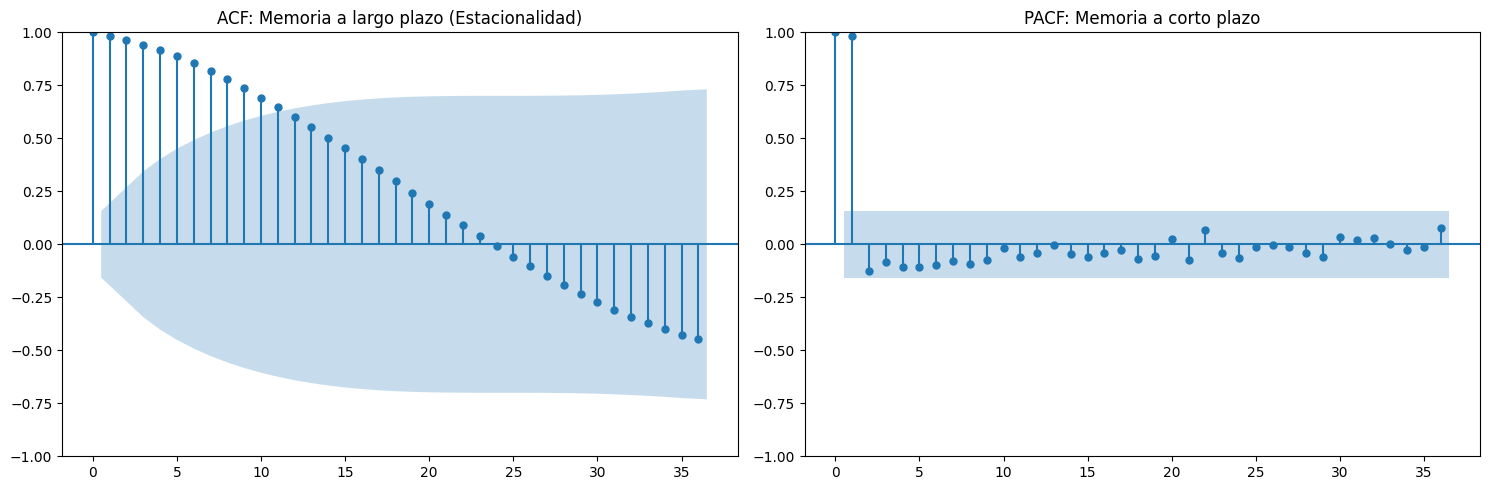

In [10]:
# 1. Definir el nombre exacto de la lista que nos pasaste
producto_objetivo = 'MAYONESA DOY PACK' 

# 2. Crear la serie temporal limpia
df_serie = df_final[df_final['producto'] == producto_objetivo].copy()
df_serie['fecha'] = pd.to_datetime(df_serie['fecha'])
df_serie = df_serie.set_index('fecha').sort_index()

# Agrupar por mes (Media Nacional)
serie_tiempo = df_serie['precio_kg'].resample('MS').mean().fillna(method='ffill')

print(f"✅ Serie lista para {producto_objetivo}")
print(f"Registros encontrados: {len(df_serie)}")

# 3. Gráficas de Autocorrelación
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ACF: Si ves picos cada 12 meses, la estacionalidad es real.
plot_acf(serie_tiempo, ax=ax[0], lags=36)
ax[0].set_title('ACF: Memoria a largo plazo (Estacionalidad)')

# PACF: Nos dice cuántos meses anteriores influyen directamente en el hoy.
plot_pacf(serie_tiempo, ax=ax[1], lags=36)
ax[1].set_title('PACF: Memoria a corto plazo')

plt.tight_layout()
plt.show()

## Grafica Estacionario y Corto plazo de varios categorías de productos

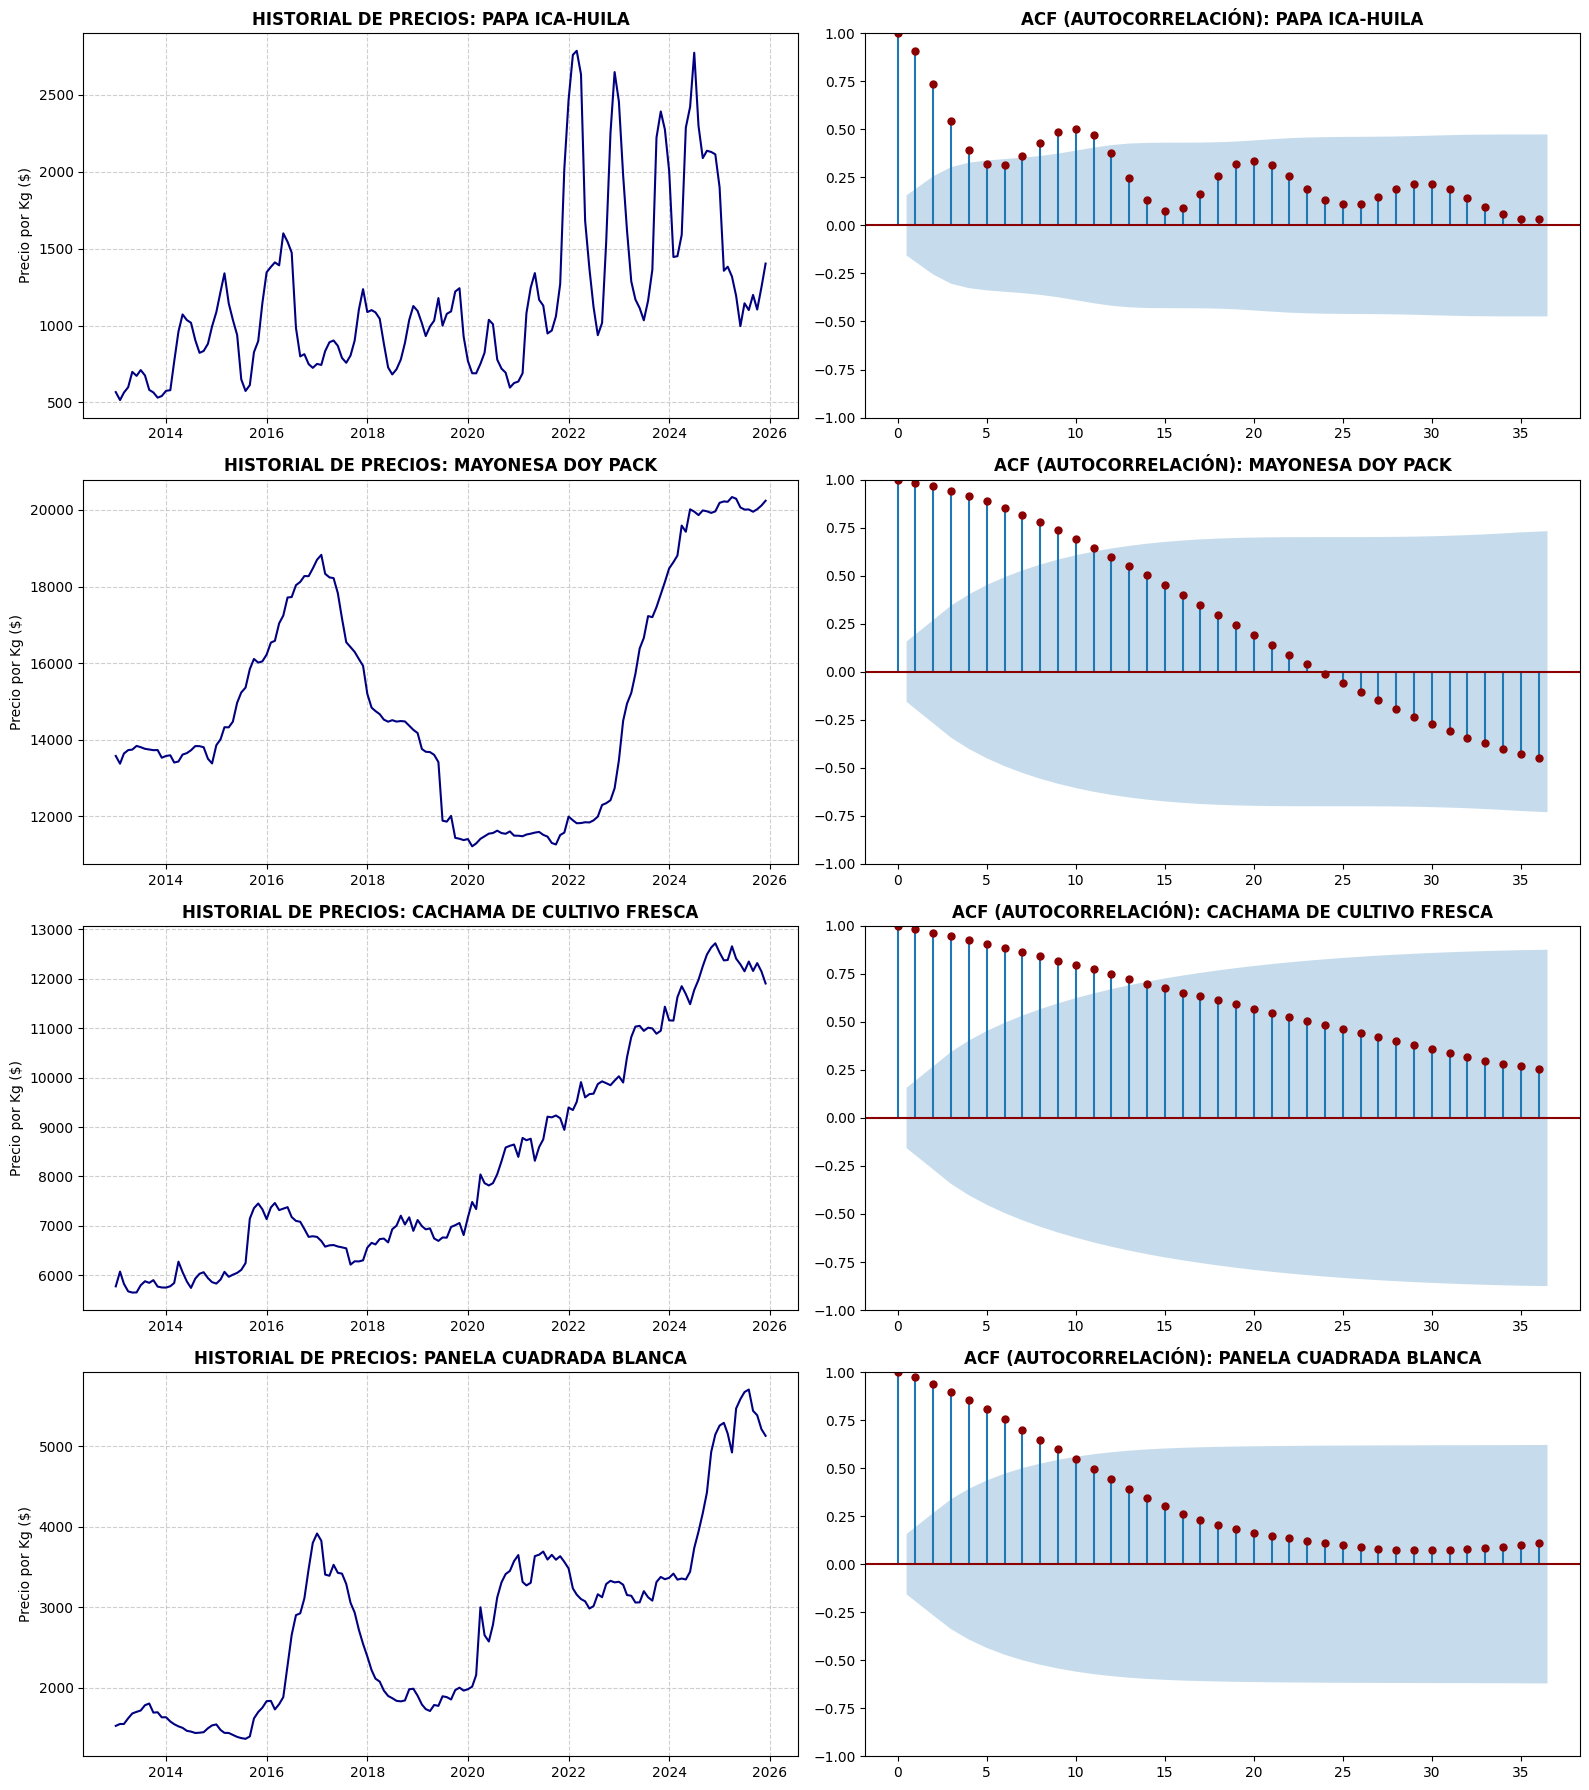

In [11]:
# 1. Selección de productos basada en tu array exacto
productos_test = [
    'PAPA ICA-HUILA', 
    'MAYONESA DOY PACK', 
    'CACHAMA DE CULTIVO FRESCA', 
    'PANELA CUADRADA BLANCA'
]

# 2. Configurar la matriz de gráficos (4 filas x 2 columnas)
fig, axes = plt.subplots(len(productos_test), 2, figsize=(16, 18))

for i, prod in enumerate(productos_test):
    # Filtrado riguroso con el nombre del array
    df_temp = df_final[df_final['producto'] == prod].copy()
    
    if df_temp.empty:
        print(f"⚠️ Advertencia: No se encontraron datos para {prod}")
        continue
    
    # Preparar la serie: Índice de fecha -> Remuestreo mensual -> Media
    df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])
    serie = df_temp.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    
    # --- Columna 1: Comportamiento Histórico (La "Cara" del producto) ---
    axes[i, 0].plot(serie, color='navy', linewidth=1.5)
    axes[i, 0].set_title(f"HISTORIAL DE PRECIOS: {prod}", fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel("Precio por Kg ($)")
    axes[i, 0].grid(True, linestyle='--', alpha=0.6)
    
    # --- Columna 2: ACF (La "Memoria" o Estacionalidad) ---
    # El ACF nos dirá qué parámetros de SARIMA usar
    plot_acf(serie, ax=axes[i, 1], lags=36, color='darkred')
    axes[i, 1].set_title(f"ACF (AUTOCORRELACIÓN): {prod}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 📝 Resumen de Hallazgos: Tipología de Series de Tiempo (SIPSA 2013-2026)

Tras el análisis exploratorio de los **156 meses** de datos, se identifican tres comportamientos distintos que condicionan la configuración del modelo **SARIMA**:

### 1. Perfil Agrícola Estacional (Ej: Papa ICA-Huila)
- **Comportamiento:** Presenta oscilaciones cíclicas marcadas con picos de precio que se repiten anualmente.
- **Firma del ACF:** Muestra "olas" de autocorrelación. Los picos que sobresalen cada 12 meses confirman una estacionalidad fuerte.
- **Implicación para SARIMA:** Requiere obligatoriamente parámetros estacionales $(P, D, Q)_{12}$ activos para capturar los ciclos de cosecha.

### 2. Perfil Industrial con Tendencia e Inercia (Ej: Mayonesa / Cachama)
- **Comportamiento:** El precio no "vuelve" a un promedio, sino que se desplaza en una dirección (ascendente por inflación o costos de producción).
- **Firma del ACF:** Los picos decaen muy lentamente en forma de rampa. No hay "olas" claras, lo que indica que el precio de hoy está amarrado casi totalmente al del mes inmediatamente anterior.
- **Implicación para SARIMA:** El modelo debe enfocarse en la **Diferenciación** ($d=1$) para estabilizar la tendencia. El componente estacional ($S$) es menos relevante que el componente autoregresivo ($p$).

### 3. Perfil de Choque y Estabilidad Mixta (Ej: Panela Cuadrada)
- **Comportamiento:** Combina periodos de estabilidad con saltos repentinos de precio.
- **Firma del ACF:** Decaimiento rápido hacia la zona de ruido (franja azul).
- **Implicación para SARIMA:** Es una serie que requiere mayor atención en los términos de **Media Móvil** ($q$) para suavizar los "choques" o saltos inesperados en el mercado.

---

### 💡 Conclusión para el Modelado
No se puede aplicar un **Auto-ARIMA** global sin antes segmentar los productos. Los productos agrícolas frescos necesitan modelos con **memoria de 12 meses**, mientras que los procesados necesitan modelos que sigan la **inercia del costo de vida**.


In [12]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 721278 entries, 163158 to 103944
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   fecha      721278 non-null  datetime64[ns]
 1   grupo      721278 non-null  object        
 2   producto   721278 non-null  object        
 3   mercado    721278 non-null  object        
 4   precio_kg  721278 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 33.0+ MB


## BUSQUEDA DE PRODUCTOS

In [13]:
resultados_producto = df_final[df_final['producto'].str.contains('PAPA', case=False, na=False)]

# Para ver qué productos únicos encontró
print(resultados_producto['producto'].unique())

['PAPA FRITA' 'PAPA CRIOLLA PARA LAVAR' 'PAPA CRIOLLA SUCIA'
 'PAPA CRIOLLA LIMPIA' 'PAPA ICA-HUILA' 'PAPA MORASURCO' 'PAPA NEVADA'
 'PAPA CAPIRA' 'PAPA R-12 NEGRA' 'PAPA R-12 ROJA' 'PAPA SABANERA'
 'PAPA SAN FELIX' 'PAPA SUPREMA' 'PAPA RUBI' 'PAPA ROJA PERUANA'
 'PAPA PARDA PASTUSA' 'PAPA PURACE' 'PAPA UNICA' 'PAPA TOCANA'
 'PAPA TOCARRENA' 'CARNE DE CERDO, TOCINO PAPADA' 'PAPAYA MARADOL'
 'PAPAYA MELONA' 'PAPAYA REDONDA' 'PAPAYA HAWAIANA' 'PAPA BETINA'
 'PAPA SUPERIOR' 'PAPAYA TAINUNG' 'PAPAYA PAULINA']


In [25]:
import pmdarima as pm

def entrenador_sipsa_resiliente(df, producto):
    # 1. Preparar serie
    df_serie = df[df['producto'] == producto].copy()
    serie = df_serie.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    
    n_meses = len(serie)
    print(f"Análisis para {producto}: {n_meses} meses encontrados.")

    # 2. Decisión lógica basada en la longitud (Tu hallazgo)
    if n_meses < 12:
        # Muy pocos datos: Modelo simple sin estacionalidad
        es_estacional = False
        m_periodo = 1
    elif n_meses < 24:
        # Datos suficientes para 1 año, pero inestables para ciclos largos
        es_estacional = True
        m_periodo = 12 
        # Forzamos una búsqueda simple
    else:
        # Serie robusta (Como tu Papa ICA-Huila de 156 meses)
        es_estacional = True
        m_periodo = 12

    # 3. Auto-ML con parámetros adaptativos
    modelo = pm.auto_arima(serie,
                           seasonal=es_estacional, 
                           m=m_periodo,
                           max_p=3, max_q=3, # Limitamos complejidad para series cortas
                           suppress_warnings=True,
                           stepwise=True)
    
    return modelo, serie

# Ejemplo de uso
modelo_papa, serie_papa = entrenador_sipsa_resiliente(df_final, 'PAPA ICA-HUILA')
print(modelo_papa.summary())

Análisis para PAPA ICA-HUILA: 156 meses encontrados.
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  156
Model:             SARIMAX(3, 1, 1)x(0, 0, 1, 12)   Log Likelihood               -1019.280
Date:                           do., 12 abr. 2026   AIC                           2050.560
Time:                                    19:57:20   BIC                           2068.821
Sample:                                01-01-2013   HQIC                          2057.977
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9867      0.099      9.918      0.000       

# 1. Interpretación de Resultados: PAPA CRIOLLA PARA LAVAR

El modelo que el **Auto-ML** eligió fue un **SARIMAX(0, 1, 0, 12)**. ¿Qué significa esto para un humano?

*   **El (0, 1, 0):** Significa que el modelo decidió que la mejor forma de entender el precio es mirando la diferencia entre el mes actual y el anterior ($d=1$). No encontró una relación matemática estable con los meses inmediatamente anteriores ($p=0, q=0$).
*   **El (12):** Detectó que hay un ciclo cada 12 meses. 

> [!CAUTION]
> **Diagnóstico Crítico:**  
> Al observar el *Sample* (01-2013 a 07-2014), ¡solo tienes un año y medio de datos!
>
> Con solo **19 meses**, el modelo está "adivinando" la estacionalidad basándose en un solo ciclo completo. El valor **Prob(JB): 0.85** es bueno (indica que los errores se distribuyen normal), pero el modelo es muy simple porque no tiene "historia" suficiente para ser complejo.


## PRODUCTOS ATEMPORALES LARGOS 1

In [15]:
# Contar meses por producto y mercado
robustez_productos = df_final.groupby(['producto', 'mercado'])['fecha'].nunique().reset_index()
robustez_productos.columns = ['producto', 'mercado', 'meses_disponibles']

# Filtrar los que tienen más de 120 meses (10 años de historia)
top_robustas = robustez_productos[robustez_productos['meses_disponibles'] <= 12].sort_values(by='meses_disponibles', ascending=False)

print("Productos ideales para pruebas SARIMA (Más de 10 años de datos):")
print(top_robustas.head(10))

Productos ideales para pruebas SARIMA (Más de 10 años de datos):
                                producto                         mercado  \
97                    AGUACATE CHOQUETTE  SAN VICENTE FERRER (ANTIOQUIA)   
2845  GALLETAS DULCES REDONDAS CON CREMA                PEREIRA, MERCASA   
779           BAGRE RAYADO ENTERO FRESCO         SANTA MARTA (MAGDALENA)   
2833  GALLETAS DULCES REDONDAS CON CREMA                 ARAUCA (ARAUCA)   
3496                      LECHE EN POLVO                 ARAUCA (ARAUCA)   
3488                    LANGOSTINO 16-20       PALMIRA (VALLE DEL CAUCA)   
607          ARVEJA VERDE SECA IMPORTADA       MONTERIA, MERCADO DEL SUR   
6104                      REPOLLO MORADO              CALI, SANTA HELENA   
3666                 LIMON COMUN CIENAGA              CUCUTA, CENABASTOS   
1129        CAMARON TIGRE PRECOCIDO SECO       PALMIRA (VALLE DEL CAUCA)   

      meses_disponibles  
97                   12  
2845                 12  
779                 

## PRODUCTOS ATEMPORALES LARGOS 2

In [16]:
# 1. Primero identificamos las combinaciones (producto, mercado) con suficiente historia
conteo_meses = df_final.groupby(['producto', 'mercado'])['fecha'].nunique().reset_index()
conteo_meses.columns = ['producto', 'mercado', 'meses_disponibles']

# 2. Aplicamos el doble filtro: Nombre contiene 'PAPA' Y Meses >= 120
papas_robustas = conteo_meses[
    (conteo_meses['producto'].str.contains('PAPA ICA', case=False, na=False)) & 
    (conteo_meses['meses_disponibles'] <= 120)
].sort_values(by=['producto', 'meses_disponibles'], ascending=[True, False])

# 3. Resultados
print(f"Se encontraron {len(papas_robustas)} combinaciones de PAPA con más de 10 años de datos:")
print(papas_robustas)

# Opcional: Si quieres ver solo la lista de nombres de productos únicos que cumplen esto:
print("\nProductos únicos encontrados:")
print(papas_robustas['producto'].unique())


Se encontraron 6 combinaciones de PAPA con más de 10 años de datos:
            producto                         mercado  meses_disponibles
4913  PAPA ICA-HUILA               LA UNION (NARINO)                 98
4909  PAPA ICA-HUILA      BUCARAMANGA, CENTROABASTOS                 78
4915  PAPA ICA-HUILA              TUQUERRES (NARINO)                 33
4910  PAPA ICA-HUILA              CUCUTA, CENABASTOS                 28
4911  PAPA ICA-HUILA                IPIALES (NARINO)                  9
4912  PAPA ICA-HUILA  LA PARADA (NORTE DE SANTANDER)                  8

Productos únicos encontrados:
['PAPA ICA-HUILA']


## MOTOR DE DECISION

--- 🤖 Analizando: CAFE MOLIDO (156 meses de datos) ---


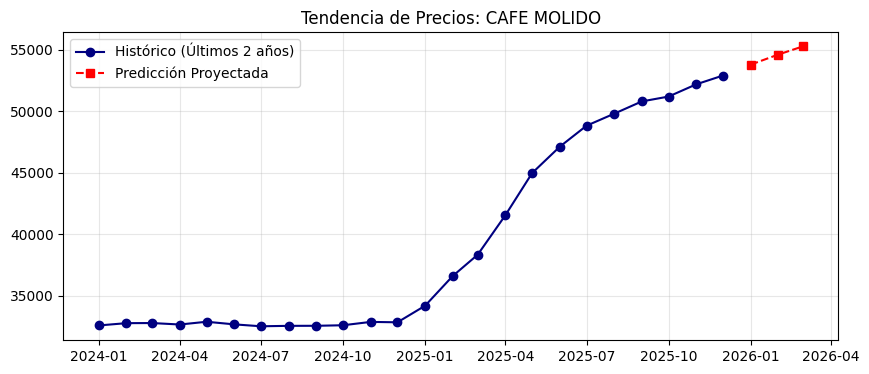


--------------------------------------------------
📊 DIAGNÓSTICO: CAFE MOLIDO
🔍 Modelo aplicado: SARIMA (Ciclos de cosecha)
💰 Precio hoy: $52,909 | Proyección mes 1: $53,794 (⚖️ ESTABLE)
--------------------------------------------------
👨‍🌾 CONSEJO PARA EL PRODUCTOR:
   👍 PRECIO JUSTO. Puede vender con tranquilidad; no se esperan cambios bruscos.

🛒 CONSEJO PARA EL CONSUMIDOR:
   👍 PRECIO ESTABLE. Compre lo necesario; el mercado está en equilibrio.
--------------------------------------------------

--- 🤖 Analizando: PAPA CRIOLLA SUCIA (156 meses de datos) ---


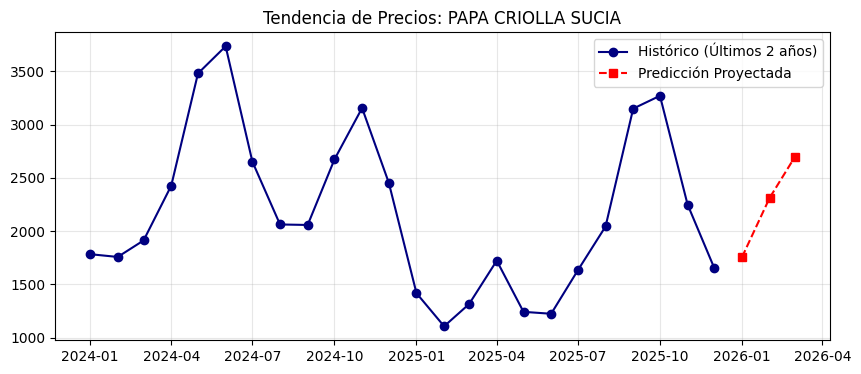


--------------------------------------------------
📊 DIAGNÓSTICO: PAPA CRIOLLA SUCIA
🔍 Modelo aplicado: SARIMA (Ciclos de cosecha)
💰 Precio hoy: $1,651 | Proyección mes 1: $1,755 (📈 ALZA)
--------------------------------------------------
👨‍🌾 CONSEJO PARA EL PRODUCTOR:
   ⚠️ NO VENDA TODAVÍA. El precio subirá. Espere a la próxima semana para mejorar su margen.

🛒 CONSEJO PARA EL CONSUMIDOR:
   🚨 COMPRE YA. El precio va hacia arriba. Abastézcase antes de que suba más.
--------------------------------------------------



In [17]:
import pmdarima as pm
import matplotlib.pyplot as plt
import pandas as pd

def consultor_agricola_sipsa(df, nombre_producto):
    # 1. Preparación de la Serie
    df_serie = df[df['producto'] == nombre_producto].copy()
    if df_serie.empty:
        return f"❌ El producto '{nombre_producto}' no se encuentra en la base de datos."
    
    # Resample mensual y limpieza de nulos
    serie = df_serie.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    n_meses = len(serie)
    precio_actual = serie.iloc[-1]

    # 2. Selección Inteligente de Modelo (Auto-ML)
    # Si hay menos de 24 meses, desactivamos la estacionalidad (SARIMA -> ARIMA)
    tiene_historia_estacional = n_meses >= 24
    
    print(f"--- 🤖 Analizando: {nombre_producto} ({n_meses} meses de datos) ---")
    modelo = pm.auto_arima(serie, 
                           seasonal=tiene_historia_estacional, 
                           m=12, 
                           stepwise=True, 
                           suppress_warnings=True)
    
    # 3. Predicción a 3 meses (Corto plazo para decisión inmediata)
    pronostico = modelo.predict(n_periods=3) # Proyectamos 3 meses para ver la tendencia completa
    precio_futuro = pronostico.iloc[0] # Precio del próximo mes
    variacion = ((precio_futuro - precio_actual) / precio_actual) * 100

    # 4. Lógica de Consejos (Equidad y Estabilidad)
    tipo_modelo = "SARIMA (Ciclos de cosecha)" if modelo.seasonal_order[3] > 0 else "ARIMA (Tendencia de costos)"
    
    if variacion > 3:
        status, emoji = "ALZA", "📈"
        p_adv = "⚠️ NO VENDA TODAVÍA. El precio subirá. Espere a la próxima semana para mejorar su margen."
        c_adv = "🚨 COMPRE YA. El precio va hacia arriba. Abastézcase antes de que suba más."
    elif variacion < -3:
        status, emoji = "BAJA", "📉"
        p_adv = "🚨 VENDA LO ANTES POSIBLE. La oferta está aumentando y el precio caerá pronto."
        c_adv = "✅ ESPERE PARA COMPRAR. En unos días el precio será más favorable para su bolsillo."
    else:
        status, emoji = "ESTABLE", "⚖️"
        p_adv = "👍 PRECIO JUSTO. Puede vender con tranquilidad; no se esperan cambios bruscos."
        c_adv = "👍 PRECIO ESTABLE. Compre lo necesario; el mercado está en equilibrio."

    # 5. Interfaz Visual en Colab
    plt.figure(figsize=(10, 4))
    plt.plot(serie.tail(24), label='Histórico (Últimos 2 años)', color='navy', marker='o')
    plt.plot(pronostico, label='Predicción Proyectada', color='red', linestyle='--', marker='s')
    plt.title(f"Tendencia de Precios: {nombre_producto}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Imprimir el Reporte Final
    print(f"\n{'-'*50}")
    print(f"📊 DIAGNÓSTICO: {nombre_producto}")
    print(f"🔍 Modelo aplicado: {tipo_modelo}")
    print(f"💰 Precio hoy: ${precio_actual:,.0f} | Proyección mes 1: ${precio_futuro:,.0f} ({emoji} {status})")
    print(f"{'-'*50}")
    print(f"👨‍🌾 CONSEJO PARA EL PRODUCTOR:")
    print(f"   {p_adv}")
    print(f"\n🛒 CONSEJO PARA EL CONSUMIDOR:")
    print(f"   {c_adv}")
    print(f"{'-'*50}\n")

# --- PRUEBA CON TUS PRODUCTOS ---
# Puedes cambiar el nombre por cualquier otro de tu lista
consultor_agricola_sipsa(df_final, 'CAFE MOLIDO')
consultor_agricola_sipsa(df_final, 'PAPA CRIOLLA SUCIA')

## MEJORA MOTOR DE DECISION 1

Este ya no solo muestra la predicción sino que muestra que tan confiable es el modelo

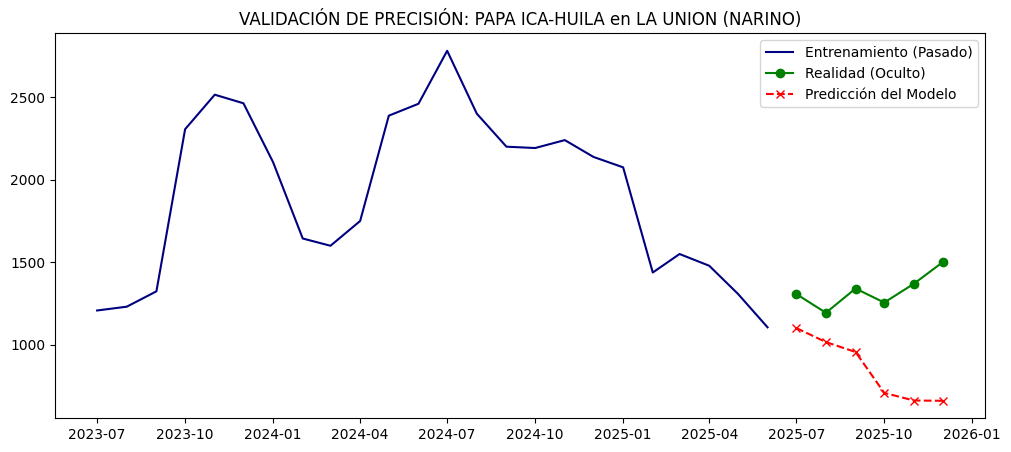


📊 REPORTE DE CALIDAD ACADÉMICA (Backtesting):
📍 Mercado: LA UNION (NARINO)
📉 Error Promedio (MAE): $476.83 pesos
🎯 Precisión del Modelo: 64.94%
💡 Interpretación: El modelo se equivoca en un 35.1% respecto al precio real.


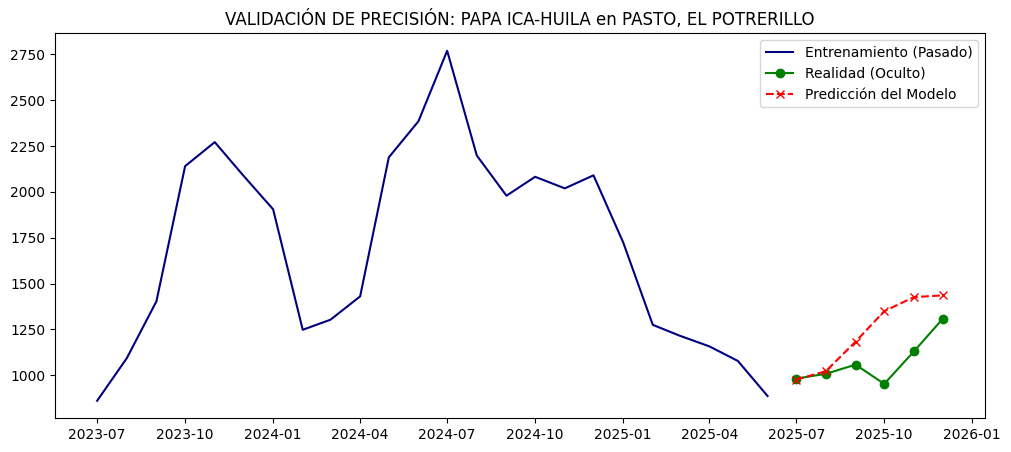


📊 REPORTE DE CALIDAD ACADÉMICA (Backtesting):
📍 Mercado: PASTO, EL POTRERILLO
📉 Error Promedio (MAE): $161.07 pesos
🎯 Precisión del Modelo: 84.75%
💡 Interpretación: El modelo se equivoca en un 15.2% respecto al precio real.


In [18]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def validador_sipsa_profesional(df, producto, mercado):
    # 1. Filtrado por Producto y Mercado (Objetivo Regional)
    df_local = df[(df['producto'] == producto) & (df['mercado'] == mercado)].copy()
    
    if len(df_local) < 12:
        return f"⚠️ Datos insuficientes para {mercado}. Se requieren al menos 12 meses."

    serie = df_local.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    
    # 2. División Académica (Train/Test Split)
    # Dejamos los últimos 6 meses para validar
    train = serie[:-6]
    test = serie[-6:]
    
    # 3. Entrenar Modelo solo con datos de entrenamiento
    modelo = pm.auto_arima(train, seasonal=(len(train)>=24), m=12, stepwise=True)
    
    # 4. Predicción de validación
    pred_validacion = modelo.predict(n_periods=6)
    
    # 5. Cálculo de Métricas de Calidad
    mae = mean_absolute_error(test, pred_validacion)
    mape = mean_absolute_percentage_error(test, pred_validacion) * 100
    
    # --- VISUALIZACIÓN DE VALIDACIÓN ---
    plt.figure(figsize=(12, 5))
    plt.plot(train.tail(24), label='Entrenamiento (Pasado)', color='navy')
    plt.plot(test, label='Realidad (Oculto)', color='green', marker='o')
    plt.plot(test.index, pred_validacion, label='Predicción del Modelo', color='red', linestyle='--', marker='x')
    plt.title(f"VALIDACIÓN DE PRECISIÓN: {producto} en {mercado}")
    plt.legend()
    plt.show()

    print(f"\n📊 REPORTE DE CALIDAD ACADÉMICA (Backtesting):")
    print(f"📍 Mercado: {mercado}")
    print(f"📉 Error Promedio (MAE): ${mae:.2f} pesos")
    print(f"🎯 Precisión del Modelo: {100 - mape:.2f}%")
    print(f"💡 Interpretación: El modelo se equivoca en un {mape:.1f}% respecto al precio real.")
    
    return modelo

# PRUEBA DE RIGOR:
# Selecciona un mercado de tu lista (ej: 'BOGOTÁ, CORABASTOS')
modelo_validado = validador_sipsa_profesional(df_final, 'PAPA ICA-HUILA', 'LA UNION (NARINO)')
modelo_validado = validador_sipsa_profesional(df_final, 'PAPA ICA-HUILA', 'PASTO, EL POTRERILLO')


# PRUEBA

## VALIDACIÓN

🔬 Iniciando validación técnica para PAPA ICA-HUILA...
📊 Entrenamiento: 104 meses | Examen (Test): 6 meses


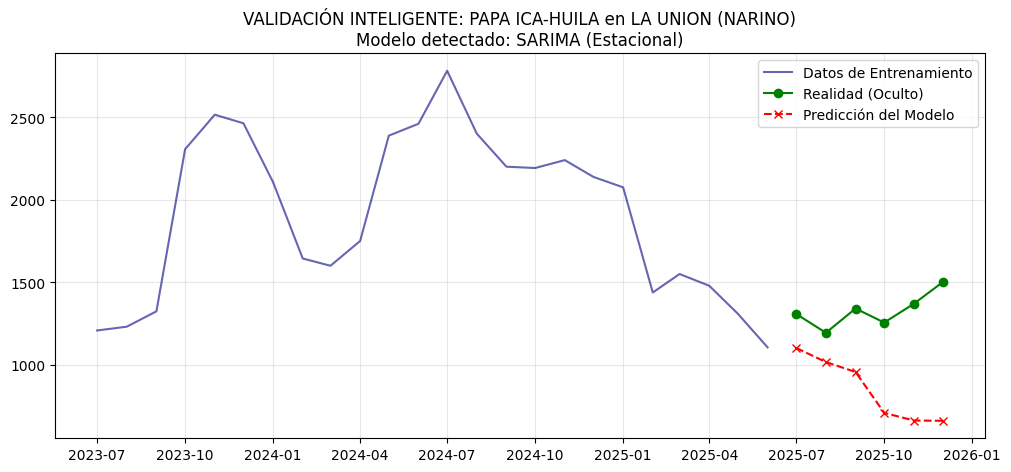


✅ REPORTE ACADÉMICO DE VALIDACIÓN:
📍 Mercado: LA UNION (NARINO)
⚙️ Algoritmo seleccionado: SARIMA (Estacional)
🎯 Precisión (100-MAPE): 64.94%
📏 Error promedio: $476.83 pesos por Kg.
💡 El modelo NO supera el umbral de confianza recomendado (80%).


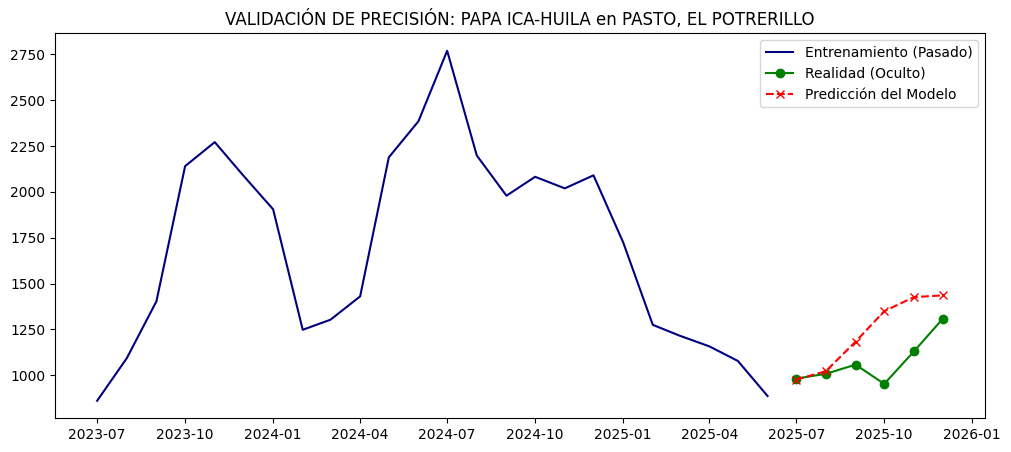


📊 REPORTE DE CALIDAD ACADÉMICA (Backtesting):
📍 Mercado: PASTO, EL POTRERILLO
📉 Error Promedio (MAE): $161.07 pesos
🎯 Precisión del Modelo: 84.75%
💡 Interpretación: El modelo se equivoca en un 15.2% respecto al precio real.


In [19]:
import numpy as np
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

def validador_inteligente_sipsa(df, producto, mercado):
    # 1. Filtrado Regional
    df_local = df[(df['producto'] == producto) & (df['mercado'] == mercado)].copy()
    
    if len(df_local) < 10:
        print(f"⚠️ {mercado}: Datos críticos ({len(df_local)} meses). No es posible validar con rigor.")
        return None

    serie = df_local.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    n_total = len(serie)
    
    # 2. Ventana de Validación Dinámica (Aquí está la inteligencia)
    # Si la serie es larga (>24 meses), validamos 6 meses. Si es corta, validamos solo el 20%.
    n_test = 6 if n_total > 24 else max(2, int(n_total * 0.2))
    n_train = n_total - n_test
    
    train = serie[:n_train]
    test = serie[n_train:]
    
    # 3. Entrenamiento Adaptativo (¿ARIMA o SARIMA?)
    # Solo intentamos SARIMA (seasonal=True) si el entrenamiento tiene al menos 20 meses
    es_estacional_posible = len(train) >= 20 
    
    print(f"🔬 Iniciando validación técnica para {producto}...")
    print(f"📊 Entrenamiento: {len(train)} meses | Examen (Test): {len(test)} meses")

    modelo = pm.auto_arima(train, 
                           seasonal=es_estacional_posible, 
                           m=12, 
                           stepwise=True, 
                           suppress_warnings=True,
                           error_action="ignore")
    
    # 4. Predicción de validación
    pred_validacion = modelo.predict(n_periods=n_test)
    
    # 5. Métricas
    mae = mean_absolute_error(test, pred_validacion)
    mape = mean_absolute_percentage_error(test, pred_validacion) * 100
    
    # Identificar qué modelo se usó para el reporte
    tipo_usado = "SARIMA (Estacional)" if modelo.seasonal_order[3] > 0 else "ARIMA (Tendencia)"

    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(12, 5))
    plt.plot(train.tail(24), label='Datos de Entrenamiento', color='navy', alpha=0.6)
    plt.plot(test, label='Realidad (Oculto)', color='green', marker='o')
    plt.plot(test.index, pred_validacion, label='Predicción del Modelo', color='red', linestyle='--', marker='x')
    plt.title(f"VALIDACIÓN INTELIGENTE: {producto} en {mercado}\nModelo detectado: {tipo_usado}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\n✅ REPORTE ACADÉMICO DE VALIDACIÓN:")
    print(f"📍 Mercado: {mercado}")
    print(f"⚙️ Algoritmo seleccionado: {tipo_usado}")
    print(f"🎯 Precisión (100-MAPE): {100 - mape:.2f}%")
    print(f"📏 Error promedio: ${mae:.2f} pesos por Kg.")
    print(f"💡 El modelo {'SÍ' if (100-mape)>80 else 'NO'} supera el umbral de confianza recomendado (80%).")
    
    return modelo

# PRUEBA:
# Ahora funcionará incluso si Corabastos tiene pocos meses, porque ajustará el test automáticamente.
modelo_validado = validador_inteligente_sipsa(df_final, 'PAPA ICA-HUILA', 'LA UNION (NARINO)')
modelo_validado = validador_sipsa_profesional(df_final, 'PAPA ICA-HUILA', 'PASTO, EL POTRERILLO')

#modelo_validado = validador_inteligente_sipsa(df_final, 'AGUACATE CHOQUETTE', 'SAN VICENTE FERRER (ANTIOQUIA)')

## TOMA DE DECISIONES

--- 🤖 Analizando Mercado: LA UNION (NARINO) (110 meses) ---


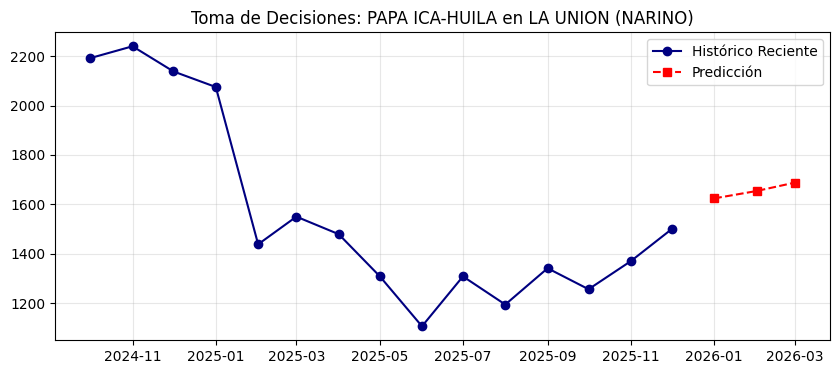


📊 DIAGNÓSTICO PARA: LA UNION (NARINO)
🔍 Modelo aplicado: SARIMA (Ciclos de cosecha)
💰 Precio hoy: $1,500 | Precio Futuro: $1,624 | Tendencia: ALZA (📈 8.3%)
👨‍🌾 PARA EL PRODUCTOR: ⚠️ NO VENDA TODAVÍA. El precio subirá. Espere para mejorar su margen.

🛒 PARA EL CONSUMIDOR: 🚨 COMPRE YA. El precio va hacia arriba. Abastézcase antes del incremento.

--- 🤖 Analizando Mercado: PASTO, EL POTRERILLO (156 meses) ---


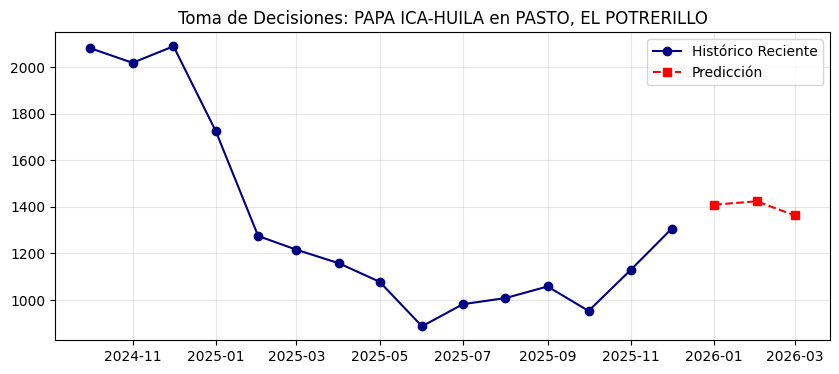


📊 DIAGNÓSTICO PARA: PASTO, EL POTRERILLO
🔍 Modelo aplicado: SARIMA (Ciclos de cosecha)
💰 Precio hoy: $1,307 | Precio Futuro: $1,409 | Tendencia: ALZA (📈 7.8%)
👨‍🌾 PARA EL PRODUCTOR: ⚠️ NO VENDA TODAVÍA. El precio subirá. Espere para mejorar su margen.

🛒 PARA EL CONSUMIDOR: 🚨 COMPRE YA. El precio va hacia arriba. Abastézcase antes del incremento.



In [20]:
def consultor_agricola_sipsa_regional(df, nombre_producto, mercado):
    # 1. Preparación de la Serie por Mercado
    df_serie = df[(df['producto'] == nombre_producto) & (df['mercado'] == mercado)].copy()
    if df_serie.empty:
        print(f"❌ No hay datos para {nombre_producto} en {mercado}.")
        return
    
    serie = df_serie.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    n_meses = len(serie)
    precio_actual = serie.iloc[-1]

    # 2. Selección Inteligente (ARIMA vs SARIMA)
    print(f"--- 🤖 Analizando Mercado: {mercado} ({n_meses} meses) ---")
    modelo = pm.auto_arima(serie, seasonal=(n_meses >= 24), m=12, stepwise=True, suppress_warnings=True)
    
    # 3. Proyección a futuro
    pronostico = modelo.predict(n_periods=3)
    precio_futuro = pronostico.iloc[0]
    variacion = ((precio_futuro - precio_actual) / precio_actual) * 100

    # 4. Lógica de Consejos (Equidad y Estabilidad)
    tipo_modelo = "SARIMA (Ciclos de cosecha)" if modelo.seasonal_order[3] > 0 else "ARIMA (Tendencia)"
    
    if variacion > 3:
        status, emoji = "ALZA", "📈"
        p_adv = "⚠️ NO VENDA TODAVÍA. El precio subirá. Espere para mejorar su margen."
        c_adv = "🚨 COMPRE YA. El precio va hacia arriba. Abastézcase antes del incremento."
    elif variacion < -3:
        status, emoji = "BAJA", "📉"
        p_adv = "🚨 VENDA LO ANTES POSIBLE. La oferta aumentará y el precio caerá."
        c_adv = "✅ ESPERE PARA COMPRAR. En unos días el precio será más favorable."
    else:
        status, emoji = "ESTABLE", "⚖️"
        p_adv = "👍 PRECIO JUSTO. Puede vender con tranquilidad."
        c_adv = "👍 PRECIO ESTABLE. Compre lo necesario; mercado equilibrado."

    # 5. Visualización
    plt.figure(figsize=(10, 4))
    plt.plot(serie.tail(15), label='Histórico Reciente', color='navy', marker='o')
    plt.plot(pronostico, label='Predicción', color='red', linestyle='--', marker='s')
    plt.title(f"Toma de Decisiones: {nombre_producto} en {mercado}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Reporte Final
    print(f"\n{'='*50}")
    print(f"📊 DIAGNÓSTICO PARA: {mercado}")
    print(f"🔍 Modelo aplicado: {tipo_modelo}")
    print(f"💰 Precio hoy: ${precio_actual:,.0f} | Precio Futuro: ${precio_futuro:,.0f} | Tendencia: {status} ({emoji} {variacion:.1f}%)")
    print(f"{'='*50}")
    print(f"👨‍🌾 PARA EL PRODUCTOR: {p_adv}")
    print(f"\n🛒 PARA EL CONSUMIDOR: {c_adv}")
    print(f"{'='*50}\n")

# Prueba
consultor_agricola_sipsa_regional(df_final, 'PAPA ICA-HUILA', 'LA UNION (NARINO)')
consultor_agricola_sipsa_regional(df_final, 'PAPA ICA-HUILA', 'PASTO, EL POTRERILLO')

## Proximos pasos

8. Hay un bloque de prebueba que se tomo como una toma de decisiones final
   Este tiene un bloque de validación y otro de toma de decisiones

9. Hay que mirar como el motor de decisiones tome la decisión cuando se muestra una precisión mayor al 80%

10. Pasarlo a Streamlit

🔬 Iniciando validación técnica para PAPA ICA-HUILA...
📊 Entrenamiento: 104 meses | Examen (Test): 6 meses


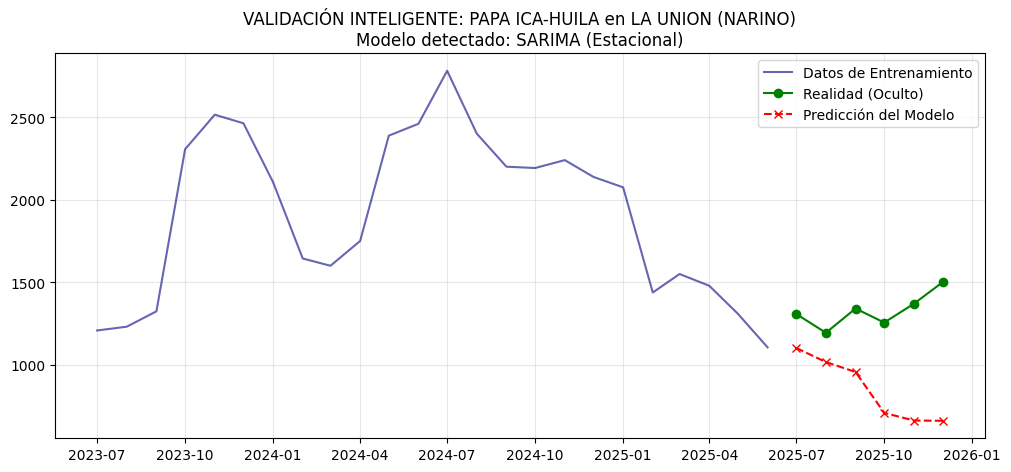


✅ REPORTE ACADÉMICO DE VALIDACIÓN:
📍 Mercado: LA UNION (NARINO)
⚙️ Algoritmo seleccionado: SARIMA (Estacional)
🎯 Precisión (100-MAPE): 64.94%
📏 Error promedio: $476.83 pesos por Kg.
💡 El modelo NO supera el umbral de confianza recomendado (80%).


In [27]:
import numpy as np
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

def validador_inteligente_sipsa(df, producto, mercado):
    # 1. Filtrado Regional
    df_local = df[(df['producto'] == producto) & (df['mercado'] == mercado)].copy()
    
    if len(df_local) < 10:
        print(f"⚠️ {mercado}: Datos críticos ({len(df_local)} meses). No es posible validar con rigor.")
        return None

    serie = df_local.set_index('fecha')['precio_kg'].resample('MS').mean().fillna(method='ffill')
    n_total = len(serie)
    
    # 2. Ventana de Validación Dinámica (Aquí está la inteligencia)
    # Si la serie es larga (>24 meses), validamos 6 meses. Si es corta, validamos solo el 20%.
    n_test = 6 if n_total > 24 else max(2, int(n_total * 0.2))
    n_train = n_total - n_test
    
    train = serie[:n_train]
    test = serie[n_train:]
    
    # 3. Entrenamiento Adaptativo (¿ARIMA o SARIMA?)
    # Solo intentamos SARIMA (seasonal=True) si el entrenamiento tiene al menos 20 meses
    es_estacional_posible = len(train) >= 20 
    
    print(f"🔬 Iniciando validación técnica para {producto}...")
    print(f"📊 Entrenamiento: {len(train)} meses | Examen (Test): {len(test)} meses")

    modelo = pm.auto_arima(train, 
                           seasonal=es_estacional_posible, 
                           m=12, 
                           stepwise=True, 
                           suppress_warnings=True,
                           error_action="ignore")
    
    # 4. Predicción de validación
    pred_validacion = modelo.predict(n_periods=n_test)
    
    # 5. Métricas
    mae = mean_absolute_error(test, pred_validacion)
    mape = mean_absolute_percentage_error(test, pred_validacion) * 100
    
    # Identificar qué modelo se usó para el reporte
    tipo_usado = "SARIMA (Estacional)" if modelo.seasonal_order[3] > 0 else "ARIMA (Tendencia)"

    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(12, 5))
    plt.plot(train.tail(24), label='Datos de Entrenamiento', color='navy', alpha=0.6)
    plt.plot(test, label='Realidad (Oculto)', color='green', marker='o')
    plt.plot(test.index, pred_validacion, label='Predicción del Modelo', color='red', linestyle='--', marker='x')
    plt.title(f"VALIDACIÓN INTELIGENTE: {producto} en {mercado}\nModelo detectado: {tipo_usado}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\n✅ REPORTE ACADÉMICO DE VALIDACIÓN:")
    print(f"📍 Mercado: {mercado}")
    print(f"⚙️ Algoritmo seleccionado: {tipo_usado}")
    print(f"🎯 Precisión (100-MAPE): {100 - mape:.2f}%")
    print(f"📏 Error promedio: ${mae:.2f} pesos por Kg.")
    print(f"💡 El modelo {'SÍ' if (100-mape)>80 else 'NO'} supera el umbral de confianza recomendado (80%).")
    
    return modelo

# PRUEBA:
# Ahora funcionará incluso si Corabastos tiene pocos meses, porque ajustará el test automáticamente.
modelo_validado = validador_inteligente_sipsa(df_final, 'PAPA ICA-HUILA', 'LA UNION (NARINO)')

In [28]:
# exportar el df_fina a parquet
df_final.to_parquet('sipsa_consolidado_2025.parquet', index=False)